In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



In [ ]:

df1 = pd.read_csv(r"C:\Users\Admin\Downloads\Energy_consumption.csv")
df2 = pd.read_csv(r"C:\Users\Admin\Downloads\Energy_consumption_extra_2000.csv")
data = pd.concat([df1, df2], ignore_index=True)
print("Combined shape:", data.shape)
# data.head(3)

Combined shape: (3000, 11)


,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
2997,2022-05-05 21:00:00,20.689580,41.837169,1765.148850,6,On,On,7.257173,Thursday,No,67.427955
2998,2022-05-05 22:00:00,20.570547,45.898218,1485.290634,7,Off,Off,11.955061,Thursday,Yes,67.519209
2999,2022-05-05 23:00:00,22.821871,34.841021,1149.381636,2,On,On,0.575187,Thursday,Yes,76.352512


In [2]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Hour']  = data['Timestamp'].dt.hour
data['Month'] = data['Timestamp'].dt.month
data['Day']   = data['Timestamp'].dt.day

# Cyclic encoding
data['hour_sin']  = np.sin(2 * np.pi * data['Hour']  / 24)
data['hour_cos']  = np.cos(2 * np.pi * data['Hour']  / 24)
data['month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)
data['day_sin']   = np.sin(2 * np.pi * data['Day']   / 31)
data['day_cos']   = np.cos(2 * np.pi * data['Day']   / 31)
data.drop(columns=['Hour', 'Month', 'Day'], inplace=True)

# Interaction features
data['HVAC_Occupancy']     = (data['HVACUsage'] == 'On').astype(int) * data['Occupancy']
data['HVAC_SqFt']          = (data['HVACUsage'] == 'On').astype(int) * data['SquareFootage']
data['Temp_Occupancy']     = data['Temperature'] * data['Occupancy']
data['Renewable_per_SqFt'] = data['RenewableEnergy'] / data['SquareFootage']
data['Temp_squared']       = data['Temperature'] ** 2
data['Occupancy_squared']  = data['Occupancy'] ** 2

print("Features after engineering:", data.shape[1], "columns")

Features after engineering: 23 columns


In [3]:
data['HVACUsage']     = (data['HVACUsage']     == 'On' ).astype(int)
data['LightingUsage'] = (data['LightingUsage'] == 'On' ).astype(int)
data['Holiday']       = (data['Holiday']       == 'Yes').astype(int)

# Fixed: one-hot encode DayOfWeek
data = pd.get_dummies(data, columns=['DayOfWeek'], drop_first=True)

print("Shape after encoding:", data.shape)

Shape after encoding: (3000, 28)


In [4]:
def remove_outliers(df, column):
    Q1, Q3 = df[column].quantile(0.25), df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5*IQR) & (df[column] <= Q3 + 1.5*IQR)]

data = remove_outliers(data, 'EnergyConsumption')
data = remove_outliers(data, 'Temperature')
print("Shape after outlier removal:", data.shape)

Shape after outlier removal: (2994, 28)


In [ ]:
X = data.drop(columns=['Timestamp', 'EnergyConsumption'])
y = data['EnergyConsumption']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)
print("Features  :", X_train.shape[1])

Train size: (2395, 26)
Test size : (599, 26)
Features  : 26


In [25]:
# rf = RandomForestRegressor(
#     n_estimators=300,
#     max_depth=15,
#     min_samples_split=2,
#     max_features='sqrt',
#     random_state=42,
#     n_jobs=-1
# )

# Train R2 : 0.9352
# Test  R2 : 0.6116
# MAE      : 4.0969
# MSE      : 26.3303

# rf = RandomForestRegressor(
#     n_estimators=300,
#     max_depth=8,
#     min_samples_split=10,
#     min_samples_leaf=5,
#     max_features='sqrt',
#     random_state=42,
#     n_jobs=-1
# )
# ```
#   Train R2 : 0.7213
#   Test  R2 : 0.6168
#   MAE      : 4.0665
#   MSE      : 25.9735



rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_split=15,
    min_samples_leaf=8,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_train_r2 = round(r2_score(y_train, rf.predict(X_train)), 4)
rf_test_r2  = round(r2_score(y_test, rf_pred), 4)
rf_mae      = round(mean_absolute_error(y_test, rf_pred), 4)
rf_mse      = round(mean_squared_error(y_test, rf_pred), 4)

print("Random Forest Results:")
print(f"  Train R2 : {rf_train_r2}")
print(f"  Test  R2 : {rf_test_r2}")
print(f"  MAE      : {rf_mae}")
print(f"  MSE      : {rf_mse}")

Random Forest Results:
  Train R2 : 0.65
  Test  R2 : 0.6087
  MAE      : 4.1298
  MSE      : 26.5259


In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [100, 200, 300, 400, 500],
    'max_depth':         [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf':  [1, 2, 4, 6, 8, 10],
    'max_features':      ['sqrt', 'log2', 0.3, 0.5]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train, y_train)
rf_pred = rf_random.predict(X_test)

rf_train_r2 = round(r2_score(y_train, rf_random.predict(X_train)), 4)
rf_test_r2  = round(r2_score(y_test, rf_pred), 4)
rf_mae      = round(mean_absolute_error(y_test, rf_pred), 4)
rf_mse      = round(mean_squared_error(y_test, rf_pred), 4)

print("Random Forest + RandomizedSearchCV Results:")
print(f"  Train R2    : {rf_train_r2}")
print(f"  Test  R2    : {rf_test_r2}")
print(f"  MAE         : {rf_mae}")
print(f"  MSE         : {rf_mse}")
print(f"  Best Params : {rf_random.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Random Forest + RandomizedSearchCV Results:
  Train R2    : 0.7172
  Test  R2    : 0.6269
  MAE         : 4.0107
  MSE         : 25.2897
  Best Params : {'n_estimators': 500, 'min_samples_split': 15, 'min_samples_leaf': 10, 'max_features': 0.3, 'max_depth': None}


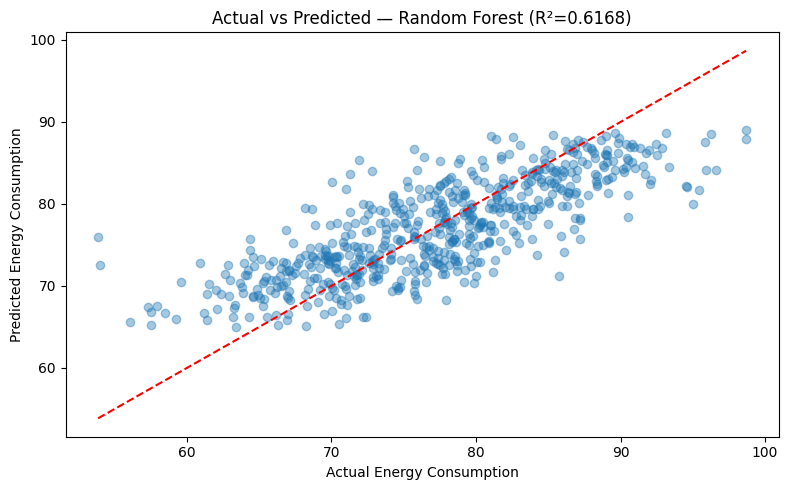

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title(f"Actual vs Predicted — Random Forest (R²={rf_test_r2})")
plt.tight_layout()
plt.show()

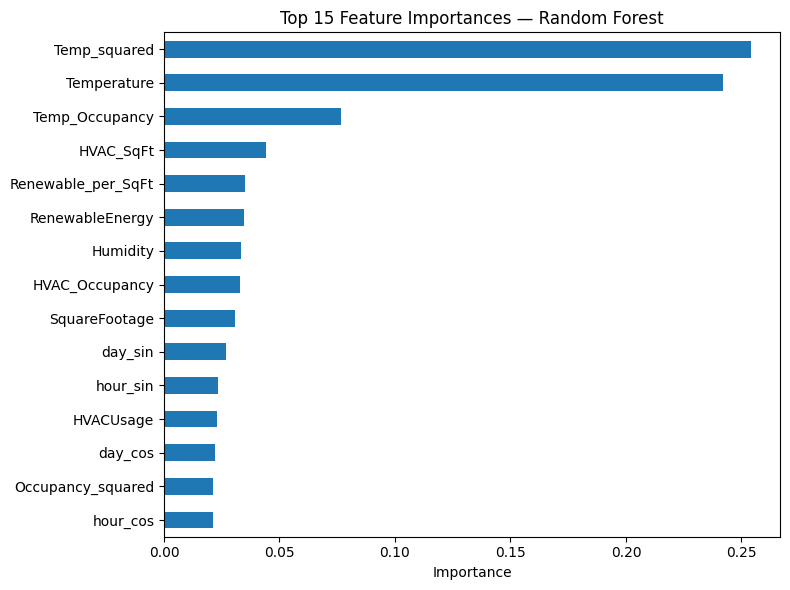

In [16]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [23]:
# # Drop features with near-zero importance
# weak_features = ['Humidity', 'SquareFootage', 'Holiday',
#                  'day_sin', 'day_cos', 'month_sin', 'month_cos']

# X_train_clean = X_train.drop(columns=weak_features)
# X_test_clean  = X_test.drop(columns=weak_features)

# rf.fit(X_train_clean, y_train)
# rf_pred = rf.predict(X_test_clean)
# print("Traib R2",round(r2_score(y_train, rf_random.predict(X_train)), 4))
# print("Test R2:", round(r2_score(y_test, rf_pred), 4))

Traib R2 0.7172
Test R2: 0.6138


In [ ]:
# import joblib

# joblib.dump(rf,                       'energy_model_rf.joblib')
# joblib.dump(X_train.columns.tolist(), 'feature_columns.joblib')

# print("Model saved successfully")

Model saved successfully
